4. Implement k-fold cross-validation on a classification model.

iris.csv 

In [1]:
pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [2]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [5]:
# Load dataset
df = pd.read_csv("iris - iris.csv")
print(df)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


In [6]:
# Display first five rows
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
# Features and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
# Create Classification Model
model = DecisionTreeClassifier(random_state=42)
# K-Fold Cross Validation (5 Folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
# Calculate Accuracy
scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

In [12]:
# Results
print("\nAccuracy for each fold:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

print("\nStandard Deviation:")
print(scores.std())
print("KHUSHI T032")


Accuracy for each fold:
[1.         0.96666667 0.93333333 0.93333333 0.93333333]

Average Accuracy:
0.9533333333333335

Standard Deviation:
0.02666666666666666
KHUSHI T032


Netflix Dataset

In [23]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

In [25]:
# Load Dataset
df = pd.read_csv("netflix_titles.csv")
print(df)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

In [28]:
# Select required columns
df = df[["release_year", "rating", "country", "type"]]
print(df)

      release_year rating                                            country  \
0             2020  PG-13                                      United States   
1             2021  TV-MA                                       South Africa   
4             2021  TV-MA                                              India   
7             1993  TV-MA  United States, Ghana, Burkina Faso, United Kin...   
8             2021  TV-14                                     United Kingdom   
...            ...    ...                                                ...   
8801          2015  TV-MA                       United Arab Emirates, Jordan   
8802          2007      R                                      United States   
8804          2009      R                                      United States   
8805          2006     PG                                      United States   
8806          2015  TV-14                                              India   

         type  
0       Movie  
1     T

In [29]:
# Remove missing values
df = df.dropna()
print(df)

      release_year rating                                            country  \
0             2020  PG-13                                      United States   
1             2021  TV-MA                                       South Africa   
4             2021  TV-MA                                              India   
7             1993  TV-MA  United States, Ghana, Burkina Faso, United Kin...   
8             2021  TV-14                                     United Kingdom   
...            ...    ...                                                ...   
8801          2015  TV-MA                       United Arab Emirates, Jordan   
8802          2007      R                                      United States   
8804          2009      R                                      United States   
8805          2006     PG                                      United States   
8806          2015  TV-14                                              India   

         type  
0       Movie  
1     T

In [35]:
# Encode categorical columns
le_rating = LabelEncoder()
le_country = LabelEncoder()
le_type = LabelEncoder()
df["rating"] = le_rating.fit_transform(df["rating"])
df["country"] = le_country.fit_transform(df["country"])
df["type"] = le_type.fit_transform(df["type"])

In [36]:
# Features and Target
X = df[["release_year", "rating", "country"]]
y = df["type"]

In [37]:
# Create Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

In [38]:
# K-Fold Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [39]:
# Accuracy Scores
scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

print("Accuracy of each fold:")
print(scores)

print("\nAverage Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())
print("KHUSHI T032")

Accuracy of each fold:
[0.7523511  0.7799373  0.76489028 0.76348808 0.7672522 ]

Average Accuracy: 0.7655837918841423
Standard Deviation: 0.00881798225911028
KHUSHI T032


-------------------------------------------------------------------------------------------

5. Implement a Decision Tree Classifier using Iris Dataset

iris.csv 

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [14]:
# Load Dataset
df = pd.read_csv("iris - iris.csv")

In [20]:
# Features and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)

In [72]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7523510971786834

Confusion Matrix:
[[989 161]
 [234 211]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1150
           1       0.57      0.47      0.52       445

    accuracy                           0.75      1595
   macro avg       0.69      0.67      0.68      1595
weighted avg       0.74      0.75      0.75      1595



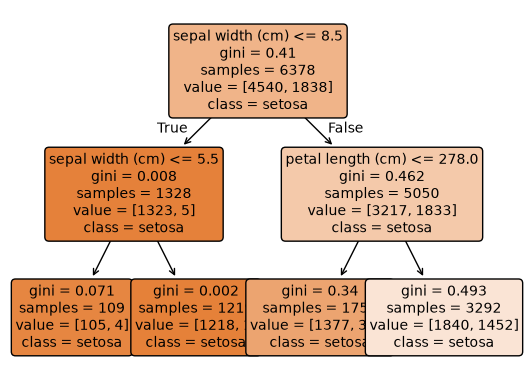

In [75]:
from sklearn.datasets import load_iris

iris = load_iris()

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.show()

Netflix Dataset

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [42]:
# Load Dataset
df = pd.read_csv("netflix_titles.csv")
print(df)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

In [52]:
# Select required columns
df = df[["release_year", "rating", "country", "type"]]
# Remove missing values
df = df.dropna()
# Encode categorical columns
le_rating = LabelEncoder()
le_country = LabelEncoder()
le_type = LabelEncoder()
df["rating"] = le_rating.fit_transform(df["rating"])
df["country"] = le_country.fit_transform(df["country"])
df["type"] = le_type.fit_transform(df["type"])
# Features and Target
X = df[["release_year", "rating", "country"]]
y = df["type"]
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Train Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)


In [63]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("KHUSHI T032")

Accuracy: 0.7523510971786834

Confusion Matrix:
[[989 161]
 [234 211]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1150
           1       0.57      0.47      0.52       445

    accuracy                           0.75      1595
   macro avg       0.69      0.67      0.68      1595
weighted avg       0.74      0.75      0.75      1595

KHUSHI T032


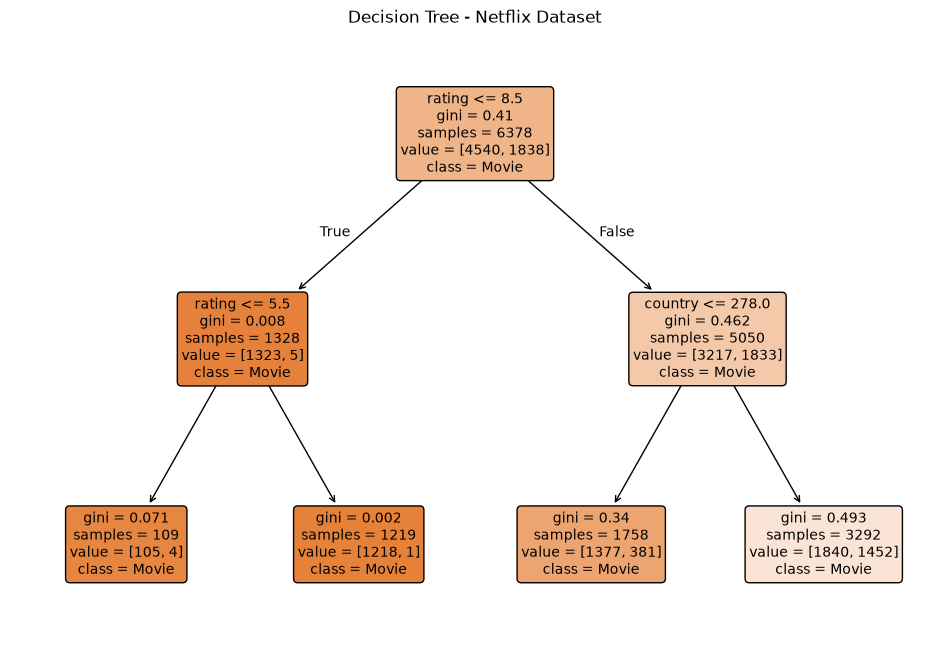

In [69]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Create Decision Tree
model = DecisionTreeClassifier(max_depth=2, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=["Movie", "TV Show"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Netflix Dataset")
plt.show()